# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [1]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score,silhouette_score,davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Importad aqui el resto de algoritmos a medida que los necesiteis:
# TSNE, AgglomerativeClustering, DBSCAN, GaussianMixture, IsolationForest, metricas...
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [2]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.
df_setitas=pd.read_csv('data/mushrooms.csv')
df_setitas.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [3]:
# Descripcion del conjunto de datos, estandar.
df_setitas.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [4]:
# Informacion sobre el tipo de datos de cada feature.
df_setitas.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

#### Calcular el número de nulos de cada feature

In [5]:
# Igual que otras veces, una linea: contar los nulos por variable.
df_setitas.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [6]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
# n_values = ...

n_values = pd.DataFrame({ 'feature': df_setitas.columns, 'n_values': [df_setitas[col].nunique() for col in df_setitas.columns] })
n_values

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [7]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.
moda_stalk_root = df_setitas[df_setitas['stalk-root'] != '?']['stalk-root'].mode()[0]
df_setitas['stalk-root'] = df_setitas['stalk-root'].replace('?', moda_stalk_root)

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [8]:
# Dejar por el camino las features con un solo valor (no aportan nada).
df_setitas = df_setitas.drop(columns=['veil-type'])

#### Separar entre variables predictoras y variable a predecir

In [9]:
# La variable a predecir es 'class'.
# y =
# X =
y = df_setitas['class']
X = df_setitas.drop(columns=['class'])

#### Codificar correctamente las variables categóricas a numéricas

In [10]:
# One Hot Encoder (una linea). Pista: pd.get_dummies
X = pd.get_dummies(X, drop_first=False)

#### Train / test split

In [11]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

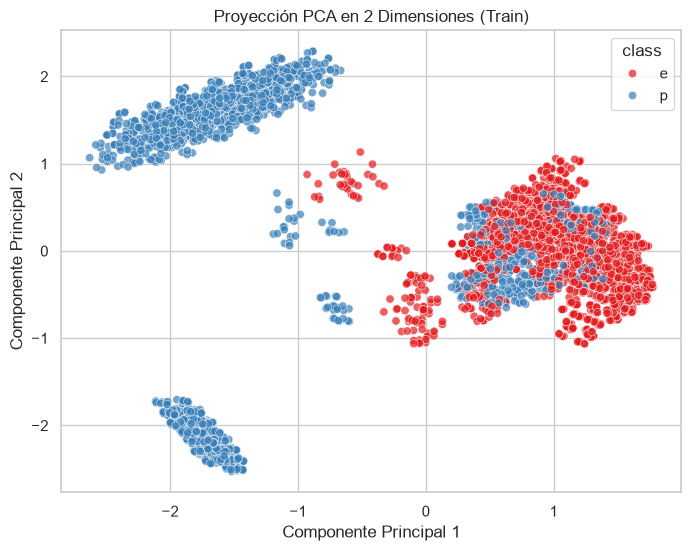

In [12]:

# metodo de sklearn
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set1', alpha=0.7)
plt.title('Proyección PCA en 2 Dimensiones (Train)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()



Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [13]:
# 1. Definir el clasificador y el numero de estimadores
clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# 2. Entrenar en train
clf.fit(X_train, y_train)
# 3. Calcular la precision sobre test
Precision = clf.score(X_test, y_test)
print(f"Precisión en el conjunto de test: {Precision:.4f}")

Precisión en el conjunto de test: 1.0000


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [14]:
X_train.shape

(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

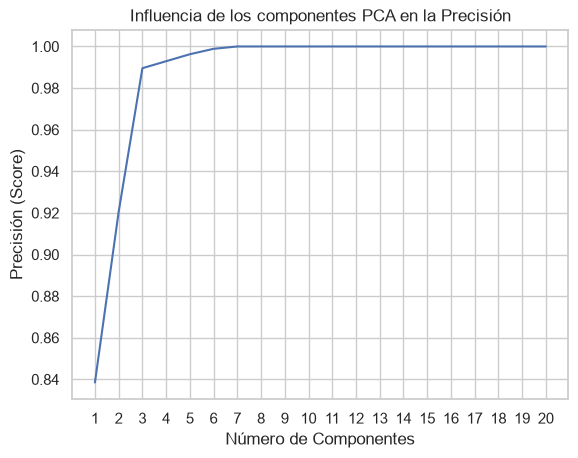

In [15]:

# definir un rango de valores a probar
n_features = range(1, 21)
scores = []

for n in n_features:
    # 1. Definir y ajustar PCA sobre X_train
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    X_train_pca_n = pca_n.fit_transform(X_train)
    X_test_pca_n = pca_n.transform(X_test)
    # 2. Entrenar Random Forest sobre los datos reducidos
    rf_n = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_n.fit(X_train_pca_n, y_train)
    # 3. Guardar el score en test
    scores.append(rf_n.score(X_test_pca_n, y_test))

sns.lineplot(x=list(n_features), y=scores)
plt.title('Influencia de los componentes PCA en la Precisión')
plt.xlabel('Número de Componentes')
plt.ylabel('Precisión (Score)')
plt.xticks(list(n_features))
plt.show()

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

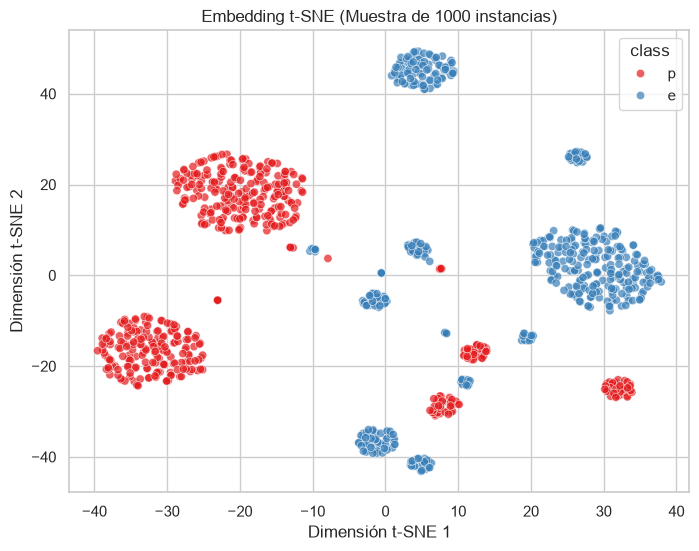

In [16]:
# 1. Tomar una muestra de X_train (t-SNE es lento)
X_sample = X_train.sample(n=1000, random_state=RANDOM_STATE)
y_sample = y_train.loc[X_sample.index]
# 2. Definir TSNE(n_components=2, ...) y ajustar
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)
# 3. Pintar el embedding coloreado por la etiqueta
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sample, palette='Set1', alpha=0.7)
plt.title('Embedding t-SNE (Muestra de 1000 instancias)')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.show()

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [17]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red
pca_10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_red = pca_10.fit_transform(X)

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

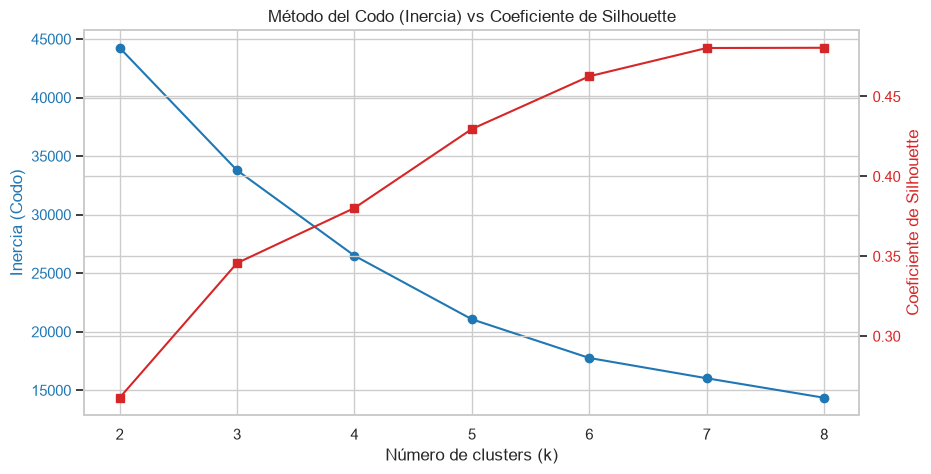

In [18]:
# definir un rango
k_values = range(2, 9)
inercias, silhouettes = [], []
for k in k_values:
    # Definir KMeans y ajustar sobre X_red
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_red)
    # Guardar la inercia (km.inertia_) y el silhouette_score
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, km.labels_))

# Pintar las dos curvas (codo y silhouette)
ig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (Codo)', color=color)
ax1.plot(k_values, inercias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silhouette', color=color)
ax2.plot(k_values, silhouettes, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo (Inercia) vs Coeficiente de Silhouette')
plt.show()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

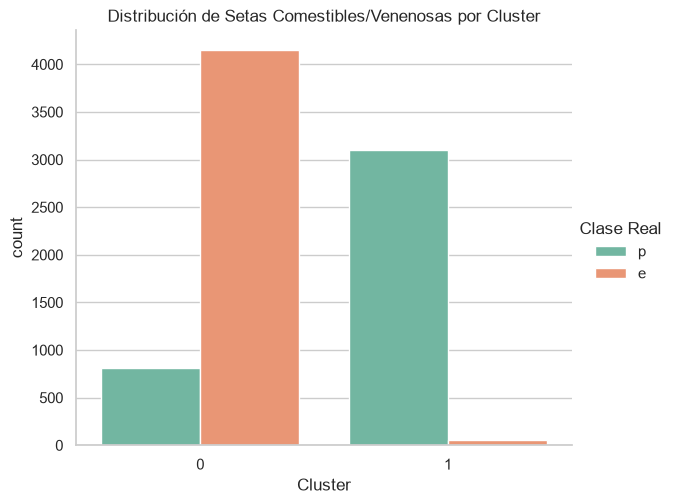

Métricas del Clustering con K-Means frente a la etiqueta real:
ARI: 0.6171
NMI: 0.5663


In [19]:
# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_red)

# Crear un DataFrame auxiliar para mapear clusters y la clase real
df_clust = pd.DataFrame({'Cluster': kmeans_labels, 'Clase Real': y})
# Calcular ARI y NMI frente a y_bin
ax = sns.catplot(x='Cluster', hue='Clase Real', data=df_clust, kind='count', palette='Set2', height=5, aspect=1.2)
plt.title('Distribución de Setas Comestibles/Venenosas por Cluster')
plt.show()

ari_km = adjusted_rand_score(y, kmeans_labels)
nmi_km = normalized_mutual_info_score(y, kmeans_labels)
print(f"Métricas del Clustering con K-Means frente a la etiqueta real:\nARI: {ari_km:.4f}\nNMI: {nmi_km:.4f}")

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [25]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
def evaluar(nombre, labels, X, y_true):
# davies_bouldin, calinski_harabasz y ARI.
    if len(set(labels) - {-1}) < 2:
        return {'Algoritmo': nombre, 'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan, 'ARI': adjusted_rand_score(y_true, labels)}
    mask = labels != -1
    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])
    ch = calinski_harabasz_score(X[mask], labels[mask])
    ari = adjusted_rand_score(y_true, labels)

    return {
        'Algoritmo': nombre, 'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch, 'ARI': ari
    }
# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
km_labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_red)
agg_labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_red)
gmm_labels = GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit_predict(X_red)
dbscan_labels = DBSCAN(eps=2.0, min_samples=5).fit_predict(X_red)

# y montar una tabla (DataFrame) comparativa.

resultados = [
    evaluar('K-Means', km_labels, X_red, y),
    evaluar('Aglomerativo', agg_labels, X_red, y),
    evaluar('Gaussian Mixture', gmm_labels, X_red, y),
    evaluar('DBSCAN (Euclidean)', dbscan_labels, X_red, y)
]

df_comp = pd.DataFrame(resultados)
df_comp

,Algoritmo,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,K-Means,0.261416,1.692939,2564.691274,0.617056
1,Aglomerativo,0.258872,1.696264,2503.624971,0.608952
2,Gaussian Mixture,0.257873,1.700914,2500.017463,0.598621
3,DBSCAN (Euclidean),0.280111,1.090698,1429.787763,0.080313


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

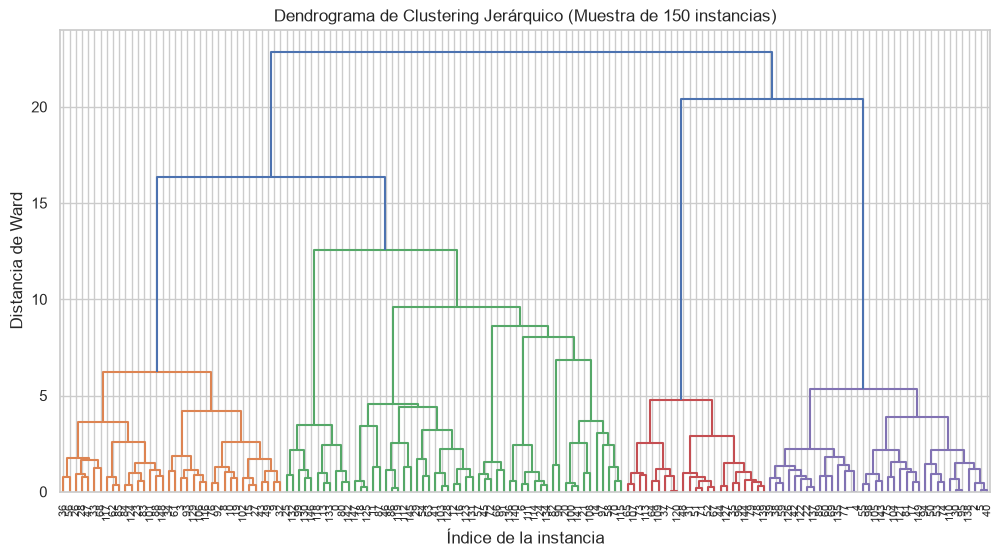

In [21]:
# 1. Tomar una muestra de X_red
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(X_red.shape[0], size=150, replace=False)
X_sample_red = X_red[idx_sample]
# 2. linkage(..., method='ward')
Z = linkage(X_sample_red, method='ward')
# 3. dendrogram(...) para visualizar la jerarquia
plt.figure(figsize=(12, 6))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrograma de Clustering Jerárquico (Muestra de 150 instancias)')
plt.xlabel('Índice de la instancia')
plt.ylabel('Distancia de Ward')
plt.show()

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [22]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
dbscan_eucl = DBSCAN(eps=1.5, min_samples=5)
labels_eucl = dbscan_eucl.fit_predict(X_red)
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).
dbscan_jacc = DBSCAN(eps=0.2, min_samples=5, metric='jaccard')
labels_jacc = dbscan_jacc.fit_predict(X)

print(f"DBSCAN (Euclidean sobre PCA) -> Clusters útiles: {len(set(labels_eucl)) - (1 if -1 in labels_eucl else 0)} | ARI: {adjusted_rand_score(y, labels_eucl):.4f}")
print(f"DBSCAN (Jaccard sobre One-Hot sin PCA) -> Clusters útiles: {len(set(labels_jacc)) - (1 if -1 in labels_jacc else 0)} | ARI: {adjusted_rand_score(y, labels_jacc):.4f}")

DBSCAN (Euclidean sobre PCA) -> Clusters útiles: 6 | ARI: 0.3736
DBSCAN (Jaccard sobre One-Hot sin PCA) -> Clusters útiles: 21 | ARI: 0.2752


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

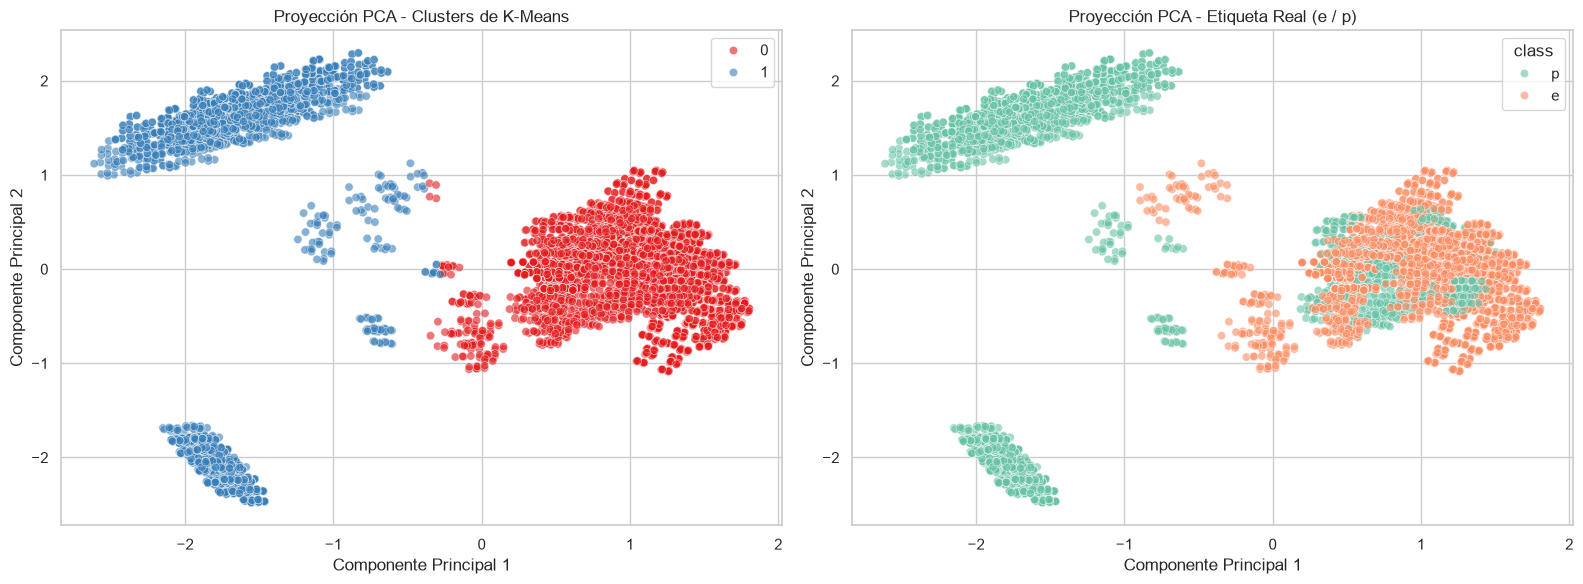

In [23]:
# Entrenar PCA(2) sobre X para representar.
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X)

km_final = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_red)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=km_final, palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Proyección PCA - Clusters de K-Means')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, palette='Set2', alpha=0.6, ax=axes[1])
axes[1].set_title('Proyección PCA - Etiqueta Real (e / p)')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

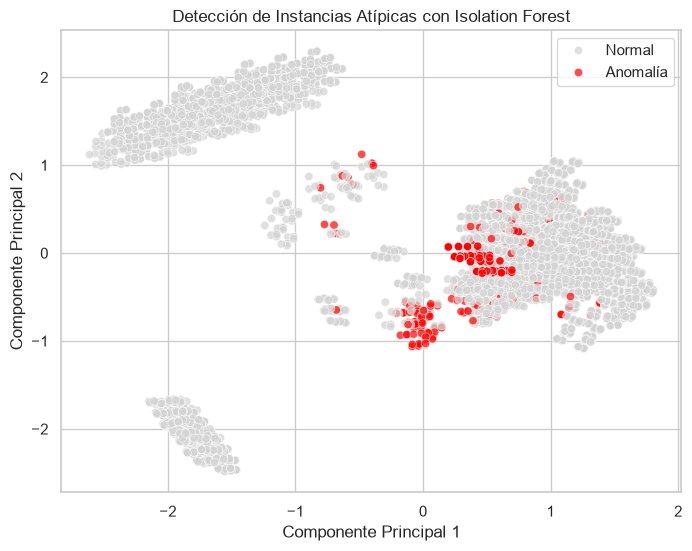

In [24]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomalias = iso_forest.fit_predict(X_red)
# 2. predict -> -1 son anomalias
anom_labels = np.where(anomalias == -1, 'Anomalía', 'Normal')
# 3. Pintarlas sobre la proyeccion PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=anom_labels, palette={'Normal': 'lightgray', 'Anomalía': 'red'}, alpha=0.7)
plt.title('Detección de Instancias Atípicas con Isolation Forest')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.